#### Importando os pacotes

In [1]:
# importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
# from scipy.stats import variation, pearsonr, kurtosis, skew, shapiro, pearsonr, kruskal, boxcox, describe
import seaborn as sns
import numpy as np
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, roc_curve, auc
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer
from sklearn.compose import make_column_selector

import eda_lib as eda
import regressao_log_lib as rl
# import hipoteses_lib as ht
from importlib import reload

In [2]:
# configurando o ambiente de visualização
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

#### Carregando o dataset

In [3]:
# carregando os dados
df_crm = pd.read_csv('../data/ml_project1_data.csv', sep=',')
df_crm.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [7]:
df_crm.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [4]:
# Dividir a base de dados em treino e teste
target = 'Response'
X = df_crm.drop(columns=target)
y = df_crm[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [10]:
df = pd.read_csv('../data/crm_eda_bivariada.csv', sep=',')
df.head()

,nivel_educacional,estado_civil,faixa_renda_anual,faixa_recencia,canal_preferencial,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,total_filhos,total_compras,total_campanhas_aceitas,Response
0,medio,Solteiro,Alta,Recente,Catalogo,635,88,546,172,88,88,0,25,0,1
1,medio,Solteiro,Media,Recente,Loja,11,1,6,2,1,6,2,6,0,0
2,medio,Casado,Muito_Alta,Muito_Recente,Loja,426,49,127,111,21,42,0,21,0,0
3,medio,Casado,Baixa,Muito_Recente,Loja,11,4,20,10,3,5,1,8,0,0
4,alto,Casado,Alta,Inativo,Loja,173,43,118,46,27,15,1,19,0,0


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   nivel_educacional        2240 non-null   str  
 1   estado_civil             2240 non-null   str  
 2   faixa_renda_anual        2216 non-null   str  
 3   faixa_recencia           2240 non-null   str  
 4   canal_preferencial       2240 non-null   str  
 5   MntWines                 2240 non-null   int64
 6   MntFruits                2240 non-null   int64
 7   MntMeatProducts          2240 non-null   int64
 8   MntFishProducts          2240 non-null   int64
 9   MntSweetProducts         2240 non-null   int64
 10  MntGoldProds             2240 non-null   int64
 11  total_filhos             2240 non-null   int64
 12  total_compras            2240 non-null   int64
 13  total_campanhas_aceitas  2240 non-null   int64
 14  Response                 2240 non-null   int64
dtypes: int64(10), s

#### Dicionário de Dados Final

| Variável               | Tipo        | Categoria            | Descrição                                                                 |
|------------------------|------------|---------------------|---------------------------------------------------------------------------|
| nivel_educacional      | string | Demográfica         | Nível educacional do cliente                                              |
| estado_civil           | string | Demográfica         | Estado civil do cliente                                                   |
| faixa_renda_anual      | string       | Demográfica         | Renda anual do cliente                                                    |
| total_filhos           | Integer     | Familiar            | Número de crianças no domicílio                                           |
| faixa_recencia         | string     | Comportamento       | Dias desde a última compra                                                |
| MntWines              | Integer  | Consumo       | Valor gasto com vinhos                         |
| MntFruits             | Integer  | Consumo       | Valor gasto com frutas                         |
| MntMeatProducts       | Integer  | Consumo       | Valor gasto com carnes                         |
| MntFishProducts       | Integer  | Consumo       | Valor gasto com peixes                         |
| MntSweetProducts      | Integer  | Consumo       | Valor gasto com doces                          |
| MntGoldProducts       | Integer  | Consumo       | Valor gasto com produtos premium (gold)        |
| total_compras        | Integer | Consumo       | Soma de todas as compras 
| canal_preferencial   | string | Consumo       | Canal preferência de compra
| total_campanhas_aceitas  | Integer | Marketing     | Campanhas aceitas                             |
| Response   | Binary | Target        | 1 se aceitou a última campanha, 0 caso contrário         |




In [12]:
# Funcão para analisar e gerar boxsplot
def quartis(df):
    linhas_df = []

    for col in df.select_dtypes(include='number').columns:
        # if df[col].dtype != 'object' or ~isinstance(col, str):
        Q1 = df[col].quantile(q = 0.25)
        Q3 = df[col].quantile(q = 0.75)

        DQ = Q3 - Q1

        LS = round(Q3 + 1.5*DQ, 2)
        LI = round(Q1 - 1.5*DQ, 2)

        acima = len(df[df[col] > LS])
        abaixo = len(df[df[col] < LI])

        if acima > 0 or abaixo > 0:
            linhas_df.append({
                'Coluna': col,
                'LS': LS,
                'Acima': acima,
                'LI': LI,
                'Abaixo': abaixo
            })
        
    # Gerar um df com as informações
    return pd.DataFrame(linhas_df)

In [13]:
quartis(df)

,Coluna,LS,Acima,LI,Abaixo
0,MntWines,1225.0,35,-697.0,0
1,MntFruits,81.0,227,-47.0,0
2,MntMeatProducts,556.0,175,-308.0,0
3,MntFishProducts,120.5,223,-67.5,0
4,MntSweetProducts,81.0,248,-47.0,0
5,MntGoldProds,126.5,207,-61.5,0
6,total_filhos,2.5,53,-1.5,0
7,total_compras,40.5,2,-11.5,0
8,total_campanhas_aceitas,0.0,463,0.0,0
9,Response,0.0,334,0.0,0


- Criar as Variáveis Derivadas (Feature Engineering)
    - nivel_educacional
    - estado_civil
    - faixa_renda_anual
    - faixa_recencia
    - canal_preferencial
    - total_filhos
    - total_compras
    - total_campanhas_aceitas 
- Para as variáveis derivadas categoricas criar as dummies com OneHotEncoder
- Para as variáveis númericas lineares aplicar StandardScaler - Para os modelos lineares.
     

In [14]:
df.head(10)

,nivel_educacional,estado_civil,faixa_renda_anual,faixa_recencia,canal_preferencial,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,total_filhos,total_compras,total_campanhas_aceitas,Response
0,medio,Solteiro,Alta,Recente,Catalogo,635,88,546,172,88,88,0,25,0,1
1,medio,Solteiro,Media,Recente,Loja,11,1,6,2,1,6,2,6,0,0
2,medio,Casado,Muito_Alta,Muito_Recente,Loja,426,49,127,111,21,42,0,21,0,0
3,medio,Casado,Baixa,Muito_Recente,Loja,11,4,20,10,3,5,1,8,0,0
4,alto,Casado,Alta,Inativo,Loja,173,43,118,46,27,15,1,19,0,0
5,alto,Casado,Alta,Muito_Recente,Loja,520,42,98,0,42,14,1,22,0,0
6,medio,Outros,Alta,Recente,Loja,235,65,164,50,49,27,1,21,0,0
7,alto,Casado,Baixa,Recente,Loja,76,10,56,3,1,23,1,10,0,0
8,alto,Casado,Baixa,Muito_Recente,Web,14,0,24,3,3,2,1,6,0,1
9,alto,Casado,Baixa,Pouco_Ativo,Web,28,0,6,1,1,13,2,2,1,0


In [5]:
class CustomImputer(BaseEstimator, TransformerMixin):
    """
        CustomImputer com regras de negócio.
        Deve ser aplicado antes de qualquer ColumnTransformer.
    """
    def __init__(self, ):
        self.income = None
        self.feature_names_in_ = None        

    def fit(self, X, y=None):

        X = pd.DataFrame(X).copy()
        self.feature_names_in_ = X.columns.tolist()
        self.expected_columns = X.columns
        
        # Mediana global
        self.income = X['Income'].median()

        return self
    
    def transform(self, X):
        X = X.copy()
        
        if not all(col in X.columns for col in self.expected_columns):
            raise ValueError("Colunas inconsistentes entre fit e transform")
             
        # -------- IMPUTAÇÕES --------
        
        # mediana global
        X['Income'] = X['Income'].fillna(self.income)

        self.feature_names_in_ = X.columns.tolist()
        return X
    
    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_)

In [6]:
# Criando a classe FeatureEngineering para criar variáveis numéricas e categóricas derivadas
class FeatureEngineering(BaseEstimator, TransformerMixin):
    """
        Cria as variáveis totalizadoras: total_filhos, total_compras, total_campanhas_aceitas
        Cria as variáveis categóricas derivadas: nivel_educacional, estado_civil, faixa_renda_anual, faixa_recencia, canal_preferencial
    """
    def __init__(self) -> None:
        self.expected_columns = None
        self.feature_names_in_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.feature_names_in_ = X.columns.tolist()
        self.expected_columns = X.columns
        return self
    
    def transform(self, X):
        X = X.copy()
        
        if not all(col in X.columns for col in self.expected_columns):
            raise ValueError("Colunas inconsistentes entre fit e transform")

        ### Criando as variáveis numéricas derivadas

        # criando a variavel total_filhos
        X['total_filhos'] = X['Kidhome'] + X['Teenhome']

        # criando a variavel total_compras = soma do número de compras com os produtos
        X['total_compras'] = X['NumDealsPurchases'] + X['NumWebPurchases'] + X['NumCatalogPurchases'] + X['NumStorePurchases']

        # criar variaval total_campanhas_aceitas = soma das campanhas aceitas
        X['total_campanhas_aceitas'] = X['AcceptedCmp1'] + X['AcceptedCmp2'] + X['AcceptedCmp3'] + X['AcceptedCmp4'] + X['AcceptedCmp5']

        ### Criando as variáveis categóricas derivadas
        
        # criando as variaveis de percentual de compras por tipo de canal
        X['pct_compras_web'] = np.where(X['total_compras'] > 0, X['NumWebPurchases'] / X['total_compras'], 0)
        X['pct_compras_catalog'] = np.where(X['total_compras'] > 0, X['NumCatalogPurchases'] / X['total_compras'], 0)
        X['pct_compras_store'] = np.where(X['total_compras'] > 0, X['NumStorePurchases'] / X['total_compras'], 0)

        nivel_educacional = np.select(
            [
                X['Education'].isin(['Basic', '2n Cycle']),
                X['Education'].isin(['Graduation']),
                X['Education'].isin(['Master', 'PhD'])
            ],
            [
                "baixo",
                "medio",
                "alto"
            ],
            default="Missing"
        )
        # Cria a variável categórica 
        X['nivel_educacional'] = nivel_educacional

        estado_civil = np.select(
            [
                X['Marital_Status'].isin(['Alone', 'Absurd', 'YOLO', 'Divorced']),
                X['Marital_Status'].isin(['Married', 'Together']),
                X['Marital_Status'].isin(['Widow']),
                X['Marital_Status'].isin(['Single'])
            ],
            [
                "Others",
                "Married",
                "Widow",
                "Single"
            ],
            default="Missing"
        )
        # Cria a variável categórica
        X['estado_civil'] = estado_civil

        faixa_renda_anual = pd.qcut(
            X['Income'],
            q=4,
            labels=['Baixa', 'Media', 'Alta', 'Muito_Alta']
        )
        # Cria a variável categórica
        X['faixa_renda_anual'] = faixa_renda_anual

        faixa_recencia = pd.cut(
            X['Recency'],
            bins=[-1, 30, 60, 90, 120],
            labels=['Muito_Recente', 'Recente', 'Pouco_Ativo', 'Inativo']
        )
        # Cria a variável categórica
        X['faixa_recencia'] = faixa_recencia

        # criando a variavel canal_preferencial = canal de compra preferencial do cliente utilizando a função idxmax para identificar o canal com maior percentual de compras
        canal_cols = [
            'pct_compras_store',
            'pct_compras_web',
            'pct_compras_catalog'
        ]

        mapa = {
            'pct_compras_store': 'Loja',
            'pct_compras_web': 'Web',
            'pct_compras_catalog': 'Catalogo'
        }

        X['canal_preferencial'] = (
            X[canal_cols]
            .idxmax(axis=1)
            .map(mapa)
        )

        self.feature_names_in_ = X.columns.tolist()
        return X
    
    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_in_)

In [7]:
categorical_cols = [
    'nivel_educacional',
    'estado_civil',
    'faixa_renda_anual',
    'faixa_recencia',
    'canal_preferencial'
]

In [8]:
# Conjunto de variáveis númericas
numeric_linear_cols = ['MntWines',
                       'MntFruits',
                       'MntMeatProducts',
                       'MntFishProducts',
                       'MntSweetProducts',
                       'MntGoldProds',
                       'total_filhos',
                       'total_compras',
                       'total_campanhas_aceitas']

In [9]:
imputer_pipeline = Pipeline(steps=[
    ("imputer", CustomImputer())
])

In [10]:
feature_engineering_pipeline = Pipeline(steps=[
    ("feature_engineer", FeatureEngineering()),
])

In [11]:
categorical_cols_pipeline = Pipeline(steps=[
    ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

In [12]:
numeric_linear_cols_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

In [13]:
# Definindo o preprocessamento para modelos baseados em arvores.
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("categorical_cols_pipeline",
         categorical_cols_pipeline,
         categorical_cols
        ),        
        ("scaler",
         "passthrough",
         numeric_linear_cols
        ),
        ("missing_flags", 
         "passthrough",
         make_column_selector(pattern="_is_missing"))
    ],
    remainder="drop"
)

In [ ]:
# Definindo o preprocessamento para modelos lineares, onde as variáveis numéricas são escaladas.
preprocessor_linear = ColumnTransformer(
    transformers=[
        ("categorical_cols_pipeline",
         categorical_cols_pipeline,
         categorical_cols
        ),        
        ("scaler",
         numeric_linear_cols_pipeline,
         numeric_linear_cols
        ),
        ("missing_flags", 
         "passthrough",
         make_column_selector(pattern="_is_missing"))
    ],
    remainder="drop"
)

In [15]:
pipeline_decision_tree = Pipeline(steps=[
    ("imputer", imputer_pipeline),
    ("feature_enginneering", feature_engineering_pipeline),
    ("preprocessor", preprocessor_tree),
    ("model", DecisionTreeClassifier(random_state=42))
    ])

In [16]:
pipeline_random_forest = Pipeline(steps=[
    ("imputer", imputer_pipeline),    
    ("feature_enginneering", feature_engineering_pipeline),
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestClassifier(random_state=42))
    ])

In [17]:
pipeline_xgboost = Pipeline(steps=[
    ("imputer", imputer_pipeline),    
    ("feature_enginneering", feature_engineering_pipeline),    
    ("preprocessor", preprocessor_tree),
    ("model", XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
    ])

In [18]:
pipeline_logistic_lasso = Pipeline(steps=[
    ("imputer", imputer_pipeline),
    ("feature_enginneering", feature_engineering_pipeline),    
    ("preprocessor", preprocessor_linear),
    ("model", LogisticRegression(penalty='l1', solver='saga', random_state=42, max_iter=1000))
    ])

In [19]:
pipeline_logistic_ridge = Pipeline(steps=[
    ("imputer", imputer_pipeline),
    ("feature_enginneering", feature_engineering_pipeline),    
    ("preprocessor", preprocessor_linear),
    ("model", LogisticRegression(penalty='l2', solver='saga', random_state=42, max_iter=1000))
    ])

In [20]:
pipeline_elasticnet = Pipeline(steps=[
    ("imputer", imputer_pipeline),
    ("feature_enginneering", feature_engineering_pipeline),    
    ("preprocessor", preprocessor_linear),
    ("model", LogisticRegression(penalty='elasticnet', solver='saga', random_state=42, max_iter=1000))
    ])

#### Treinado os modelos utilizando GridSearch e CrossValidation

In [23]:
models = {
    "DecisionTree": (
        pipeline_decision_tree,
        {
            'model__criterion': ['gini', 'entropy'],
            'model__max_depth': [3, 5, 10],
            'model__min_samples_split': [2, 5, 10]
        }
    ),
    "RandomForest": (
        pipeline_random_forest,
        {
            'model__n_estimators': [50, 100, 200],
            'model__max_depth': [5, 10, None],
            'model__min_samples_split': [2, 5, 10]
        }
    ),    
    "XGBoost": (
        pipeline_xgboost,
        {
            'model__n_estimators': [50, 100, 200],
            'model__max_depth': [3, 5, 10],
            'model__learning_rate': [0.1, 0.2, 0.3]
        }
    ),
    "LogisticLasso": (
        pipeline_logistic_lasso,
        {
            'model__C': [0.01, 0.1, 1, 10]
        }
     ),
    "LogisticRidge": (
        pipeline_logistic_ridge,
        {
            'model__C': [0.01, 0.1, 1, 10]
        }
    ),
     "LogisticElasticNet": (
        pipeline_elasticnet,
        {
            'model__C': [0.01, 0.1, 1, 10],
            'model__l1_ratio': [0.1, 0.5, 0.9]
        }
    )
}

best_model = None
best_model_name = None
grid_search = None
best_auc = 0
results_all = {}
modelos_treinados = {}
for model_name, (pipe, params) in models.items():
    print(f"Treinando {model_name}...")

    # GridSearch para tunar os hiperparâmetros (somente para modelos que possuem hiperparâmetros definidos)
    if params is not None:
        grid_search = GridSearchCV(
            pipe,
            param_grid=params,
            cv=3,
            scoring='roc_auc',
            n_jobs=-1,
            return_train_score=True,
            error_score='raise'
        )
    else:
        grid_search = None

    if grid_search:
        grid_search.fit(X_train, y_train)
        best_estimator = grid_search.best_estimator_
        best_score = grid_search.best_score_

        #armazenando os modelos já treinados no gridsearch
        modelos_treinados[model_name] = grid_search.best_estimator_
        modelos_treinados[model_name + '_best_auc'] = grid_search.best_score_
    else:
        pipe.fit(X_train, y_train)
        best_estimator = pipe
        y_train_prob = pipe.predict_proba(X_train)[:, 1]
        best_score = roc_auc_score(y_train, y_train_prob)

if grid_search:
    print(f"Resultados de Cross-Validation para todos os modelos no conjunto de treino:")
    for model_name in models.keys():    
        print(f'Modelo: {model_name} | AUC: {modelos_treinados[model_name + "_best_auc"]:.4f}')

Treinando DecisionTree...
Treinando RandomForest...
Treinando XGBoost...
Treinando LogisticLasso...
Treinando LogisticRidge...
Treinando LogisticElasticNet...
Resultados de Cross-Validation para todos os modelos no conjunto de treino:
Modelo: DecisionTree | AUC: 0.7744
Modelo: RandomForest | AUC: 0.8359
Modelo: XGBoost | AUC: 0.8360
Modelo: LogisticLasso | AUC: 0.8354
Modelo: LogisticRidge | AUC: 0.8366
Modelo: LogisticElasticNet | AUC: 0.8365


#### Calcular métricas no threshold padrão (0.5) para os modelos no conjunto de teste
- Isso serve como baseline.


Desempenho no conjunto de teste para todos os modelos:
Modelo: DecisionTree | Acurácia: 0.8646 | AUC: 0.7927 | Precisão: 0.6047 | Recall: 0.2600
Modelo: RandomForest | Acurácia: 0.8795 | AUC: 0.8562 | Precisão: 0.7714 | Recall: 0.2700
Modelo: XGBoost | Acurácia: 0.8810 | AUC: 0.8510 | Precisão: 0.7083 | Recall: 0.3400
Modelo: LogisticLasso | Acurácia: 0.8854 | AUC: 0.8426 | Precisão: 0.7170 | Recall: 0.3800
Modelo: LogisticRidge | Acurácia: 0.8824 | AUC: 0.8415 | Precisão: 0.7059 | Recall: 0.3600
Modelo: LogisticElasticNet | Acurácia: 0.8824 | AUC: 0.8416 | Precisão: 0.7059 | Recall: 0.3600


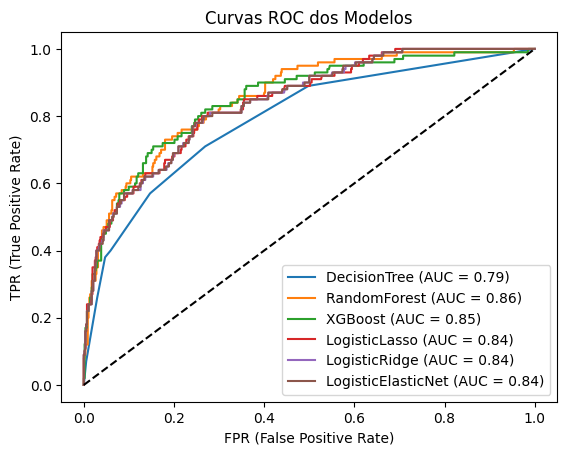

In [230]:
# 5. Verificar desempenho dos modelos no teste
print("\nDesempenho no conjunto de teste para todos os modelos:")
for model_name, model in models.items():
   
    y_test_prob = modelos_treinados[model_name].predict_proba(X_test)[:, 1]
    
    y_test_pred = (y_test_prob >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_test_pred)
    auc_score = roc_auc_score(y_test, y_test_prob)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)

    # Desenho da curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.2f})")

    print(f"Modelo: {model_name} | Acurácia: {acc:.4f} | AUC: {auc_score:.4f} | Precisão: {precision:.4f} | Recall: {recall:.4f}")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate)')
plt.title('Curvas ROC dos Modelos')
plt.legend()
plt.show()

#### Curva ROC

A ROC (Receiver Operating Characteristic) mostra a capacidade do modelo de separar os dois grupos:

- clientes com maior chance de compra
- clientes com menor chance de compra

No nosso caso, utilizando o modelo Random Forest:

- AUC ≈ 0.86

Isso significa:

Se escolhermos aleatoriamente uma cliente, o modelo atribui probabilidade maior para clinte com maior chance de compra em 86% das vezes.

Interpretação:

Imagine que existam 100 compradores reais.

O modelo encontra aproximadamente:

- 27 compradores (Recall)
- perde 73 compradores

Por outro lado, quando ele diz que alguém vai comprar:

- aproximadamente 77% realmente compram (Precision)
- aproximadamente 23% não compram, são falsos positivos

#### Eficiência dos modelos treinados

In [22]:
def calcula_lift(model: str, target: pd.Series, p_chapeu: pd.Series, n_percentis: int =10) -> pd.DataFrame:
    df_lift = pd.DataFrame({
        'model': model,
        'target': target,
        'p_chapeu': p_chapeu
    }).sort_values(by='p_chapeu', ascending=False).reset_index(drop=True)

    percentil = (100//n_percentis)
    receita_por_comprador = 10.93
    custo_por_cliente = 3

    df_lift['percentil'] = pd.qcut(df_lift.index, n_percentis, labels=[str(i) for i in range(1, n_percentis + 1)]).astype(int)*percentil

    total_de_1s_acumulado_por_percentil = df_lift.groupby('percentil')['target'].sum().cumsum()
    total_de_linhas_acumulado_por_percentil = df_lift.groupby('percentil')['target'].count().cumsum()

    # taxa de resposta = precisão => media do target por percentil acumulado.
    taxa_resposta = round(total_de_1s_acumulado_por_percentil / total_de_linhas_acumulado_por_percentil, 2)
    # lift = precisao / media geral do target
    lift = (total_de_1s_acumulado_por_percentil / total_de_linhas_acumulado_por_percentil) / df_lift['target'].mean()
    # percentual de quanto o modelo é melhor por percentil, do que um cenário aleatorio (media geral target)
    perc_lift = round((lift - 1) * 100, 2)
    clientes_contatados = ((df_lift.groupby('percentil').size().cumsum()))
    # compradores_esperados = (df_lift.groupby('percentil')['target'].sum().cumsum())
    compradores_esperados = round(clientes_contatados * taxa_resposta, 2)
    receita = round(receita_por_comprador * compradores_esperados, 2)
    custo = round(custo_por_cliente * clientes_contatados, 2)
    lucro = round(receita - custo, 2)
    roi = round((lucro / custo) * 100, 2)
    dic_lift = {
        'model': model,
        'clientes_contatados': clientes_contatados
        ,'taxa_resposta': taxa_resposta
        ,'compradores_esperados': compradores_esperados
        ,'receita': receita
        ,'custo': custo
        ,'lucro': lucro
        ,'ROI': roi
        ,'%lift': perc_lift
                }

    return pd.DataFrame(dic_lift)

Usando os dados do case:

- Campanha piloto: 2.240 clientes
- Custo total: 6.720 MU
- Receita total: 3.674 MU
- Taxa de resposta: 15%
- Lucro da campanha piloto: -3.046 MU

Cada cliente contatado custa 3 MU = (Custo total = 6720 / nro clientes = 2240).
Receita média por comprador:
- Se 15% de 2.240 clientes compraram: 2240 x 15% = 336 compradores.
- receita por comprador = (Receita total = 3674 / compradores = 336) = 10,93 MU

In [246]:
# Tabela Lift para todos os modelos treinados
for model_name, model in models.items():
   
    y_test_prob = modelos_treinados[model_name].predict_proba(X_test)[:, 1]
    lift_teste = calcula_lift(model=model_name, target=y_test, p_chapeu=y_test_prob, n_percentis=20)
    display(lift_teste)


,model,clientes_contatados,taxa_resposta,compradores_esperados,receita,custo,lucro,ROI,%lift
percentil,,,,,,,,,
5,DecisionTree,34,0.68,23.12,252.70,102,150.70,147.75,354.59
10,DecisionTree,68,0.56,38.08,416.21,204,212.21,104.02,275.53
15,DecisionTree,101,0.47,47.47,518.85,303,215.85,71.24,212.71
20,DecisionTree,135,0.41,55.35,604.98,405,199.98,49.38,178.76
25,DecisionTree,168,0.38,63.84,697.77,504,193.77,38.45,156.00
30,DecisionTree,202,0.34,68.68,750.67,606,144.67,23.87,126.22
35,DecisionTree,235,0.31,72.85,796.25,705,91.25,12.94,105.89
40,DecisionTree,269,0.29,78.01,852.65,807,45.65,5.66,92.36
45,DecisionTree,302,0.27,81.54,891.23,906,-14.77,-1.63,80.24


,model,clientes_contatados,taxa_resposta,compradores_esperados,receita,custo,lucro,ROI,%lift
percentil,,,,,,,,,
5,RandomForest,34,0.76,25.84,282.43,102,180.43,176.89,413.88
10,RandomForest,68,0.66,44.88,490.54,204,286.54,140.46,344.71
15,RandomForest,101,0.56,56.56,618.20,303,315.20,104.03,279.25
20,RandomForest,135,0.46,62.10,678.75,405,273.75,67.59,208.62
25,RandomForest,168,0.42,70.56,771.22,504,267.22,53.02,180.00
30,RandomForest,202,0.38,76.76,838.99,606,232.99,38.45,152.83
35,RandomForest,235,0.34,79.90,873.31,705,168.31,23.87,128.77
40,RandomForest,269,0.31,83.39,911.45,807,104.45,12.94,107.35
45,RandomForest,302,0.28,84.56,924.24,906,18.24,2.01,91.36


,model,clientes_contatados,taxa_resposta,compradores_esperados,receita,custo,lucro,ROI,%lift
percentil,,,,,,,,,
5,XGBoost,34,0.76,25.84,282.43,102,180.43,176.89,413.88
10,XGBoost,68,0.65,44.20,483.11,204,279.11,136.82,334.82
15,XGBoost,101,0.55,55.55,607.16,303,304.16,100.38,272.59
20,XGBoost,135,0.47,63.45,693.51,405,288.51,71.24,213.60
25,XGBoost,168,0.42,70.56,771.22,504,267.22,53.02,184.00
30,XGBoost,202,0.37,74.74,816.91,606,210.91,34.80,149.50
35,XGBoost,235,0.34,79.90,873.31,705,168.31,23.87,131.63
40,XGBoost,269,0.31,83.39,911.45,807,104.45,12.94,107.35
45,XGBoost,302,0.29,87.58,957.25,906,51.25,5.66,98.04


,model,clientes_contatados,taxa_resposta,compradores_esperados,receita,custo,lucro,ROI,%lift
percentil,,,,,,,,,
5,LogisticLasso,34,0.74,25.16,275.00,102,173.00,169.61,394.12
10,LogisticLasso,68,0.65,44.20,483.11,204,279.11,136.82,334.82
15,LogisticLasso,101,0.54,54.54,596.12,303,293.12,96.74,265.94
20,LogisticLasso,135,0.45,60.75,664.00,405,259.00,63.95,203.64
25,LogisticLasso,168,0.39,65.52,716.13,504,212.13,42.09,164.00
30,LogisticLasso,202,0.36,72.72,794.83,606,188.83,31.16,139.52
35,LogisticLasso,235,0.34,79.90,873.31,705,168.31,23.87,128.77
40,LogisticLasso,269,0.30,80.70,882.05,807,75.05,9.30,102.35
45,LogisticLasso,302,0.28,84.56,924.24,906,18.24,2.01,89.14


,model,clientes_contatados,taxa_resposta,compradores_esperados,receita,custo,lucro,ROI,%lift
percentil,,,,,,,,,
5,LogisticRidge,34,0.71,24.14,263.85,102,161.85,158.68,374.35
10,LogisticRidge,68,0.63,42.84,468.24,204,264.24,129.53,324.94
15,LogisticRidge,101,0.53,53.53,585.08,303,282.08,93.10,259.29
20,LogisticRidge,135,0.44,59.40,649.24,405,244.24,60.31,198.67
25,LogisticRidge,168,0.38,63.84,697.77,504,193.77,38.45,156.00
30,LogisticRidge,202,0.36,72.72,794.83,606,188.83,31.16,139.52
35,LogisticRidge,235,0.34,79.90,873.31,705,168.31,23.87,128.77
40,LogisticRidge,269,0.30,80.70,882.05,807,75.05,9.30,102.35
45,LogisticRidge,302,0.28,84.56,924.24,906,18.24,2.01,89.14


,model,clientes_contatados,taxa_resposta,compradores_esperados,receita,custo,lucro,ROI,%lift
percentil,,,,,,,,,
5,LogisticElasticNet,34,0.71,24.14,263.85,102,161.85,158.68,374.35
10,LogisticElasticNet,68,0.63,42.84,468.24,204,264.24,129.53,324.94
15,LogisticElasticNet,101,0.53,53.53,585.08,303,282.08,93.10,259.29
20,LogisticElasticNet,135,0.45,60.75,664.00,405,259.00,63.95,203.64
25,LogisticElasticNet,168,0.38,63.84,697.77,504,193.77,38.45,156.00
30,LogisticElasticNet,202,0.36,72.72,794.83,606,188.83,31.16,139.52
35,LogisticElasticNet,235,0.34,79.90,873.31,705,168.31,23.87,128.77
40,LogisticElasticNet,269,0.30,80.70,882.05,807,75.05,9.30,102.35
45,LogisticElasticNet,302,0.28,84.56,924.24,906,18.24,2.01,89.14


| Modelo              | Melhor Percentil |      Lucro |         ROI |        Lift | Taxa de Resposta |
| ------------------- | ---------------: | ---------: | ----------: | ----------: | ---------------: |
| Decision Tree       |              15% |     215,85 |      71,24% |     212,71% |              47% |
| Logistic Ridge      |              15% |     282,08 |      93,10% |     259,29% |              53% |
| Logistic ElasticNet |              15% |     282,08 |      93,10% |     259,29% |              53% |
| Logistic Lasso      |              15% |     293,12 |      96,74% |     265,94% |              54% |
| XGBoost             |              15% |     304,16 |     100,38% |     272,59% |              55% |
| **Random Forest**   |          **15%** | **315,20** | **104,03%** | **279,25%** |          **56%** |


In [26]:
modelos_treinados['RandomForest']

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('feature_enginneering', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineer', ...)]"
,"transform_input transform_input

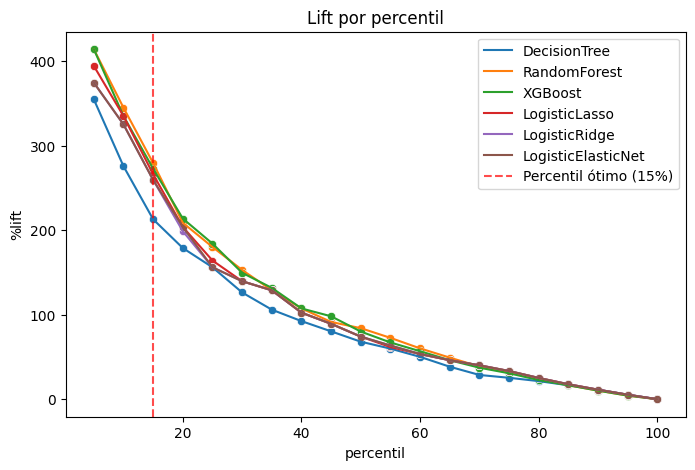

In [255]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))
for model_name, model in models.items():

    y_test_prob = modelos_treinados[model_name].predict_proba(X_test)[:, 1]
    lift_teste = calcula_lift(model=model_name, target=y_test, p_chapeu=y_test_prob, n_percentis=20)
    # criar um grafico percentil x lift
    sns.scatterplot(data=lift_teste, x='percentil', y='%lift', palette='mako_r')
    sns.lineplot(data=lift_teste, x='percentil', y='%lift', palette='mako_r', label=model_name)

plt.title('Lift por percentil')
plt.axvline(
    x=15,
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Percentil ótimo (15%)'
)
plt.legend()
plt.show()

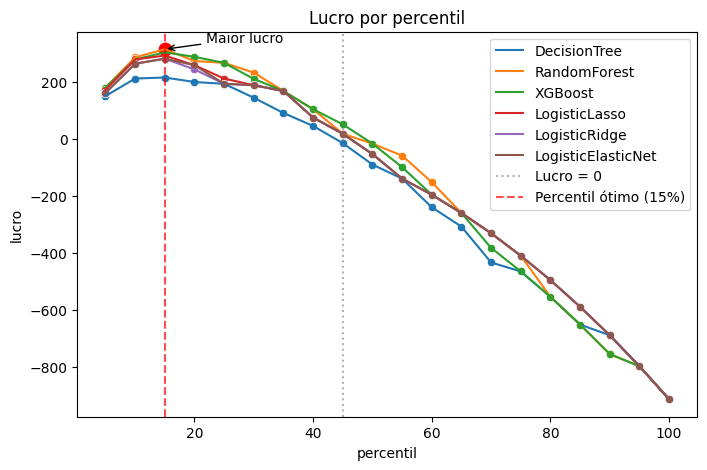

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))
for model_name, model in models.items():

    y_test_prob = modelos_treinados[model_name].predict_proba(X_test)[:, 1]
    lift_teste = calcula_lift(model=model_name, target=y_test, p_chapeu=y_test_prob, n_percentis=20)
    # criar um grafico percentil x lift
    sns.scatterplot(data=lift_teste, x='percentil', y='lucro', palette='mako_r')
    sns.lineplot(data=lift_teste, x='percentil', y='lucro', palette='mako_r', label=model_name)

plt.title('Lucro por percentil')
plt.axvline(
    x=45,
    color='gray',
    linestyle=':',
    alpha=0.6,
    label='Lucro = 0'
)
plt.axvline(
    x=15,
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Percentil ótimo (15%)'
)
plt.scatter(15, 315.2, s=80, color='red')
plt.annotate(
    'Maior lucro',
    (15, 315.2),
    xytext=(22, 340),
    arrowprops=dict(arrowstyle='->')
)
plt.legend()
plt.show()

#### Avaliação final:
>Os modelos Random Forest, XGBoost e as regressões logísticas apresentaram desempenhos bastante próximos durante a validação cruzada. Entretanto, na avaliação utilizando o conjunto de dados de teste, o Random Forest obteve a maior AUC (0,8562) e também apresentou o maior lucro, ROI e Lift na região de interesse da campanha (Top 15%), sendo selecionado como modelo final.

>Ao selecionar apenas os 15% clientes com maior probabilidade de compra, o modelo concentra aproximadamente 56% de compradores nesse grupo (taxa de resposta), proporcionando um Lift de cerca de 279%, ROI de 104% e o maior lucro esperado da campanha.

- Melhor modelo: Random Forest (AUC = 0,8562).
- O modelo no top 15% do clientes, consegue trazer um retorno 279,25% maior do que selecionar os clientes de forma aleatória.
- A campanha passa a dar prejuízo após o percentil de 45%.
- O lucro máximo ocorre no percentil de 15%
    - até 15% da base, cada novo cliente incluído ainda gera lucro.
    - acima disso, começam a entrar muitos clientes com baixa probabilidade de compra.
    - o custo adicional passa a crescer mais rápido que a receita.
    - Melhor estratégia de campanha: contatar apenas os 15% de clientes com maior probabilidade de compra.
- Resultado esperado: essa estratégia maximiza o lucro da campanha, mantendo uma taxa de resposta de aproximadamente 56%, muito superior aos 15% obtidos ao abordar toda a base.

Fazendo uma simulação para uma campanha de 1.000.000 de clientes, utilizando 15% da base, onde:
- Campanha: 150.000 clientes contatados
- Custo por cliente: 3 MU
- Custo total: 450.000 MU
- Taxa de resposta: 56%
- Compradores esperados: 84.000
- Receita média por comprador: 10,93 MU
- Receita esperada: 918.120 MU
- Lucro esperado: 468.120 MU
- ROI: 104%